In [155]:
include("./trajopt/utils.jl")
include("./trajopt/dynamics.jl")
include("./funlopt/funl_dynamics.jl")
include("./funlopt/funl_utils.jl")
include("./funlopt/funl_constraint.jl")
include("./trajopt/scaling.jl")
# Set default plot settings for academic paper
default(
    guidefont = font(12, "Times"),      # Axis label font
    legendfont = font(12, "Times"),     # Legend font
    titlefont = font(14, "Times"),      # Title font
    tickfont = font(10, "sans-serif"),  # Tick font
    grid = true                         # Enable grid lines
)

In [156]:
# load nominal trajectory
using JLD2, FileIO
using LaTeXStrings
filename = "./data/traj_result" 
@load filename my_dict
xnom = my_dict["x"]
unom = my_dict["u"]
tnom = my_dict["t"];
N = size(xnom,2) - 1
dtnom = zeros(N)
for i in 1:N
    dtnom[i] = tnom[i+1]-tnom[i]
end

In [ ]:
filename = "./data/funnel_result" 
@load filename funl_dict
Q1nom = funl_dict["Q1"]
Y1nom = funl_dict["Y1"]
lam1nom = funl_dict["lam1"];
Q2nom = funl_dict["Q2"]
Y2nom = funl_dict["Y2"]
lam2nom = funl_dict["lam"];
N1 = size(Q1nom,3) - 1
@assert(N == N1)

In [158]:
# obstacle
function get_H_obs(rx,ry)
    return diagm([1/rx,1/ry])
end
c_list = []
H_list = []
push!(c_list, [4.0, 2.5])
push!(H_list, get_H_obs(1.5, 4.0))
vmax = 2.0
vmin = 0.0
wmax = 1.5
wmin = -1.5

-1.5

In [159]:
ix = 3
iu = 2
iw = 2
dynamics = Unicycle()

Unicycle(3, 2, 2, 3, 2, 10, 5, 2, [0.0 0.0 1.0; 0.0 0.0 0.0; 0.0 0.0 0.0], [0.0 0.0; 1.0 0.0; 0.0 0.0], [1.0 0.0; 0.0 1.0; 0.0 0.0], [0.0 0.0; 0.0 0.0; 1.0 0.0], 0.03, 0.05, #undef, #undef, #undef, #undef)

# Get intersample trajectory and funnel

In [160]:
_,tprop,xprop = propagate_multiple_FOH(dynamics,xnom,unom,dtnom)

([0.0 0.45605368080255704 … 7.543918847423386 7.999993611648152; 0.0 0.1605354886837394 … 0.1605164627036123 -1.0684492663686693e-5; 0.0 0.5953215826720322 … -0.5953218635605422 4.223148254129642e-12], [0.0, 7.5e-5, 0.0008249999999999999, 0.008324999999999997, 0.03085414548416754, 0.06215007456684899, 0.09902516271982972, 0.1431291980573401, 0.19272734644366651, 0.24779065423393856  …  14.421288051427327, 14.472154433102574, 14.52771957685547, 14.587791492049384, 14.651841714168432, 14.71964593442123, 14.790969551725798, 14.86574980331131, 14.94401864182967, 15.0], [0.0 2.154783087656023e-5 … 7.982385727014699 7.999993611648152; 0.0 5.444496487902496e-10 … 0.00033411064021220225 -1.0684492663686693e-5; 0.0 5.053220924921486e-5 … -0.03821899076969245 4.223148254129642e-12])

In [161]:
Q_fit = [[LinearInterpolation(tnom, Q2nom[i,j,:], extrapolation_bc=Flat()) for j in 1:ix] for i in 1:ix ]
Y_fit = [[LinearInterpolation(tnom, Y2nom[i,j,:], extrapolation_bc=Flat()) for j in 1:ix] for i in 1:iu ]
u_fit = [LinearInterpolation(tnom, unom[idx,:],extrapolation_bc=Flat()) for idx in 1:iu]
;

In [162]:
# tplot = LinRange(tnom[1],tnom[end],201)
length_tprop = length(tprop)
Qprop = zeros(ix,ix,length_tprop)
Yprop = zeros(iu,ix,length_tprop)
uprop = zeros(iu,length_tprop)
# Qplot,Yplot = [],[]
for (idx,t) in enumerate(tprop)
    Qprop[:,:,idx] .= get_ABF_interp(t,Q_fit,ix,ix) 
    Yprop[:,:,idx] .= get_ABF_interp(t,Y_fit,iu,ix) 
    uprop[:,idx] .= get_u_interp(t,u_fit)
    # push!(Qplot,)
    # push!(Yplot,get_ABF_interp(t,Y_fit,iu,ix))
end

In [163]:
input_proj_funl_nom,Rnom = project_onto_input(Q2nom,Y2nom)
input_proj_funl_prop,Rprop = project_onto_input(Qprop,Yprop)

(Any[Any[0.28726743809541727, 0.28733625650963546, 0.288025287705541, 0.29498723121295595, 0.3162996333690747, 0.345863377672564, 0.37977033747038297, 0.41871508932093576, 0.46057537608628724, 0.5050500534528962  …  0.6066803851386363, 0.5499066149392194, 0.4995257119136564, 0.45469852234515695, 0.4148994568315537, 0.37948856747048465, 0.3480426132737007, 0.32041051420975025, 0.2974304169407839, 0.28727600339627185], Any[0.826204055826693, 0.8259441666646128, 0.8233626179880565, 0.799167085765752, 0.740565837288218, 0.682524143724792, 0.634944535600851, 0.5955682489533656, 0.5652169546437003, 0.5424693227881447  …  0.4989892646934864, 0.4865696143676625, 0.4780958648512387, 0.4745768217275885, 0.4774382283105491, 0.4889719753168958, 0.5135726749712246, 0.561321763560837, 0.6624171513689223, 0.8262247544335916]], [0.0825225809899044 -3.478234724651721e-6; -3.478234724494148e-6 0.6826131418644773;;; 0.08256212430497102 5.568744464645207e-5; 5.568744464635498e-5 0.6821837664473017;;; 0.08

# Computed funnel

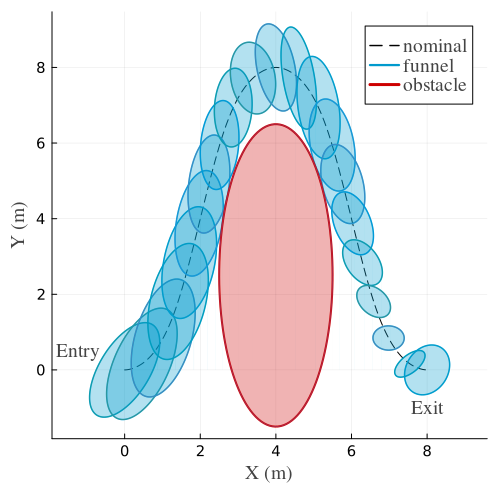

"/Users/taewankim/Documents/Code/ForPapers/2024_ECJ_Funnel_copositive/image/xy_funnels.pdf"

In [164]:
p2 = Plots.plot(; size=(500,500))
plot!(xprop[1,:],xprop[2,:],aspect_ratio=:equal,c=:black,linestyle=:dash,linewidth=1.0,label="nominal")
for idx in 1:N+1
    label = nothing
    if idx == 1
        label = "funnel"
    end
    plot_ellipse(p2,Q2nom[:,:,idx],xnom[:,idx],"deepskyblue3",linewidth=1.5,label=label,fill=true)
end
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
annotate!(-1.2,0.5,text("Entry", :black, 12, "Times"))
annotate!(8.0,-1.0,text("Exit", :black, 12, "Times"))
xlabel!("X (m)")
ylabel!("Y (m)")
display(p2)
savefig("./image/xy_funnels.pdf")

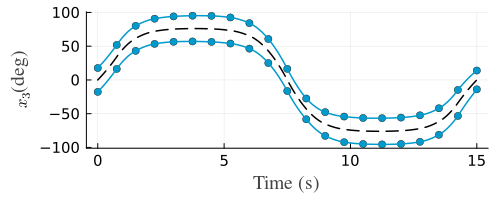

In [165]:
lW = 1.5
p3 = Plots.plot(; size=(500,200))
# plot!(tsam[1],xnomprop[1][3,:],linestyle=:dash,color="black",label="")
plot!(tprop,rad2deg.(xprop[3,:]),linewidth=lW,linestyle=:dash,color="black",label="")
scatter!(tnom,rad2deg.(xnom[3,:] + sqrt.(Q2nom[3,3,:])),linewidth=lW,seriestype = :line, marker = :circle,color="deepskyblue3",label="")
scatter!(tnom,rad2deg.(xnom[3,:] - sqrt.(Q2nom[3,3,:])),linewidth=lW,seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tprop,rad2deg.(xprop[3,:] + sqrt.(Qprop[3,3,:])),linewidth=lW,seriestype = :line,color="deepskyblue3",label="")
plot!(tprop,rad2deg.(xprop[3,:] - sqrt.(Qprop[3,3,:])),linewidth=lW,seriestype = :line,color="deepskyblue3",label="")
xlabel!("Time (s)")
ylabel!(L"x_3" * "(deg)")
plot!(bottom_margin=5Plots.mm)
plot!(left_margin=5Plots.mm)
savefig("./image/yaw_funnels.pdf")
display(p3)

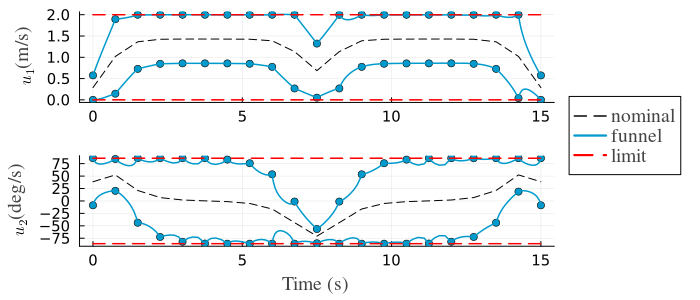

In [167]:
lW = 1.5
p1 = plot(tnom,unom[1,:],linestyle=:dash,linewidth=1,color="black",label="nominal")
scatter!(tnom,unom[1,:]+input_proj_funl_nom[1],linewidth=lW,color="deepskyblue3",label="")
scatter!(tnom,unom[1,:]-input_proj_funl_nom[1],linewidth=lW,color="deepskyblue3",label="")
plot!(tprop,uprop[1,:]+input_proj_funl_prop[1],linewidth=lW,color="deepskyblue3",label="")
plot!(tprop,uprop[1,:]-input_proj_funl_prop[1],linewidth=lW,color="deepskyblue3",label="funnel")
plot!(tnom,tnom*0 .+ vmax,linewidth=lW,linestyle=:dash,color="red",label="limit")
plot!(tnom,tnom*0 .+ vmin,linewidth=lW,linestyle=:dash,color="red",label="")
ylabel!(raw"$u_1$" * "(m/s)")
p2 = plot(tnom,rad2deg.(unom[2,:]),linewidth=1,linestyle=:dash,color="black",label="")
scatter!(tnom,rad2deg.(unom[2,:]+input_proj_funl_nom[2]),linewidth=lW,color="deepskyblue3",label="")
scatter!(tnom,rad2deg.(unom[2,:]-input_proj_funl_nom[2]),linewidth=lW,color="deepskyblue3",label="")
plot!(tprop,rad2deg.(uprop[2,:]+input_proj_funl_prop[2]),linewidth=lW,color="deepskyblue3",label="")
plot!(tprop,rad2deg.(uprop[2,:]-input_proj_funl_prop[2]),linewidth=lW,color="deepskyblue3",label="")
plot!(tnom,tnom*0 .+ rad2deg(wmax),linewidth=lW,linestyle=:dash,color="red",label="")
plot!(tnom,tnom*0 .+ rad2deg(wmin),linewidth=lW,linestyle=:dash,color="red",label="")
xlabel!("Time (s)")
ylabel!(L"u_2" * "(deg/s)")
p3 = plot(p1,p2,layout=(2,1),size=(700,300))
plot!(legend=(1.12,-0.15))
plot!(bottom_margin=5Plots.mm)
plot!(left_margin=5Plots.mm)
plot!(right_margin=35Plots.mm)
savefig("./image/input_funnels.pdf")
display(p3)

# Samples

In [168]:
num_sample = 100
xs_list = []
Random.seed!(1234)
for i in 1:num_sample
    z = randn(ix)
    z = z / norm(z)
    push!(xs_list,xnom[:,1] + sqrt(Q2nom[:,:,1]) * z)
end

In [169]:
xsam_fwd,tsam,xsam,usam,xnomprop = [],[],[],[],[]
i = 0
for xs in xs_list
    # println(i)
    i += 1
    xf_,ts_,xsam_,usam_,xnom_ = propagate_from_funnel_entry_uncertain_dynamics(xs,
        dynamics,
        xnom,unom,tnom,
        Q2nom,Y2nom)
    push!(xsam_fwd,xf_)
    push!(tsam,ts_)
    push!(xsam,xsam_)
    push!(usam,usam_)
    push!(xnomprop,xnom_)
end

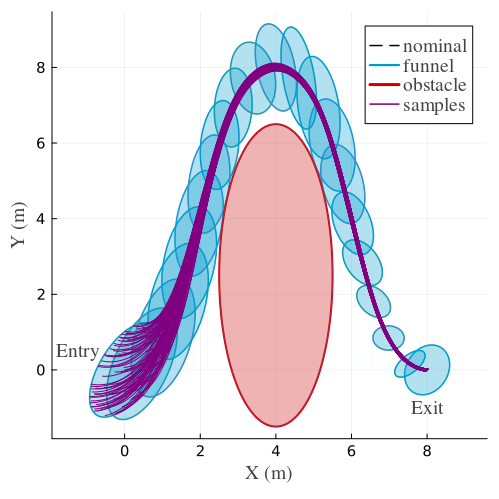

"/Users/taewankim/Documents/Code/ForPapers/2024_ECJ_Funnel_copositive/image/xy_funnels_with_samples.pdf"

In [170]:
p2 = Plots.plot(; size=(500,500))
plot!(xprop[1,:],xprop[2,:],aspect_ratio=:equal,c=:black,linestyle=:dash,linewidth=1.0,label="nominal")
for idx in 1:N+1
    label = nothing
    if idx == 1
        label = "funnel"
    end
    plot_ellipse(p2,Q2nom[:,:,idx],xnom[:,idx],"deepskyblue3",linewidth=1.5,label=label,fill=true)
end
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
for (idx,x_) in enumerate(xsam)
    label = ""
    if idx == 1
        label ="samples"
    end
    plot!(x_[1,:],x_[2,:],color="purple",label=label)
end
annotate!(-1.2,0.5,text("Entry", :black, 12, "Times"))
annotate!(8.0,-1.0,text("Exit", :black, 12, "Times"))
xlabel!("X (m)")
ylabel!("Y (m)")
display(p2)
savefig("./image/xy_funnels_with_samples.pdf")

In [171]:
# Lyapunov function
Lypsam = []
idx = 1
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    xprop_ = xnomprop[idx]
    Lyp = []
    for iode in 1:length(tsam_)
        t_ = tsam_[iode]
        x_ = xsam_[:,iode]
        xnom_ = xprop_[:,iode]
        Q_ = get_ABF_interp(t_,Q_fit,ix,ix)
        val = (x_ - xnom_)' * inv(Q_) * (x_ - xnom_)
        push!(Lyp,val)
    end
    push!(Lypsam,Lyp)
end


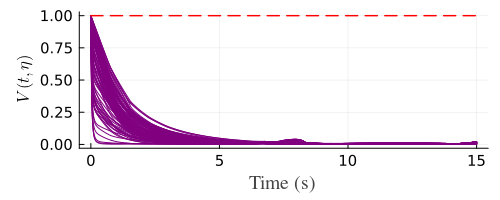

In [172]:
p3 = Plots.plot(; size=(500,200))
for idx = 1:length(tsam)
    plot!(tsam[idx],Lypsam[idx],c=:purple,label="")
end
plot!(tsam[1],tsam[1]*0 .+ 1.0,linewidth=lW,c=:red,linestyle=:dash,label="")
xlabel!("Time (s)")
ylabel!(L"V(t,\eta)")
plot!(bottom_margin=5Plots.mm)
plot!(left_margin=5Plots.mm)
savefig("./image/Lyapunov.pdf")
display(p3)